In [1]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import*
init_printing()
import numpy as np
from math import comb
from sympy.abc import x,y,z,s
k,n,m = symbols('k n m', integer=True)
t = symbols('t', real=True, negative=False)

# Problem 1

We are given the following system:

$$\dot{x}_1 = f_1(x_1, x_2) = x_2,$$

$$
\dot{x}_2 = f_2(x_1, x_2) = \mu x_1 - x_1^3.
$$

Here the two variables $x_1$ and $x_2$ depend on time $t$. A dot above a time dependent variable denotes
differentiation with respect to $t$. The parameter $\mu$ is a real number.

### 1.A

We need to determine all the critical points of the vectorfield. The critical points are determined by:
$$\dot{x}_1=x_2=0,$$
$$\dot{x}_2=\mu x_1 - x_1^3=0$$

It is easy to observe that $x_2$ must be equal to zero, in order for the system to have a critical point. We can now calculate the values for $x_1$:
$$\mu x_1 - x_1^3=0 \leftrightarrow x_1 = 0 \lor x_1 = \pm \sqrt(\mu)$$

We can therefore conclude the system has critical points in $(0,0)$ and $(\pm\sqrt(\mu),0)$


### 1.B

First we observe that, The system
$$\dot x_1 = x_2,\qquad \dot x_2=\mu x_1 - x_1^3$$
is Hamiltonian because it can be written in the form
$$\dot x_1=\frac{\partial H}{\partial x_2},\qquad
\dot x_2=-\frac{\partial H}{\partial x_1}$$

with Hamiltonian
$$H(x_1,x_2)=\frac12 x_2^2-\frac{\mu}{2}x_1^2+\frac14 x_1^4.$$
Since $\dot H = 0$, the system is conservative and trajectories lie on level curves of H.
We have now found the equilibrias, we now write the jacobian as:
$$J(x_1,x_2)=\begin{pmatrix}
\partial_{x_1}f_1 & \partial_{x_2}f_1\\[4pt]
\partial_{x_1}f_2 & \partial_{x_2}f_2
\end{pmatrix}
=
\begin{pmatrix}
0 & 1\\[4pt]
\mu-3x_1^2 & 0
\end{pmatrix}.
$$

at $(0,0)$ we have:
$$J(0,0)=\begin{pmatrix}0&1\\ \mu &0\end{pmatrix},$$
This gives us the characteristic equation $\lambda^2 - \mu=0\leftrightarrow \lambda = \pm\sqrt(\mu)$

If $\mu>0$ then we have two real eigenvalues of opposite sign ie. a saddle point, that is unstable.
If $\mu<0$ then the eigenvalues are $\lambda = \pm i \sqrt(|\mu|)$. since it is purely imaginary we have a center, that is neutrally stabil.

at $(x1,x2) = (\pm\sqrt\mu,0)$ For $\mu>0$:
$$J(\pm\sqrt{\mu},0)=\begin{pmatrix}0&1\\ \mu-3(\pm\sqrt{\mu})^2 &0\end{pmatrix}
=\begin{pmatrix}0&1\\ -2\mu &0\end{pmatrix}.$$
This gives us the characteristic equation of $\lambda^2 - 2\mu = 0 \leftrightarrow \lambda = i\pm\sqrt(2\mu)$
The eigenvalues are purely imaginary, so the linearization has the form of a center.
These equilibrium points are therefore non-hyperbolic, but since the nonlinear system is conservative (it preserves an energy function), the points $(\pm\sqrt{\mu},0)$ are in fact centers: nearby trajectories form closed orbits around each point, and the equilibrium is neutrally stable.

We can summirze this in a table:
| Parameter Case | Critical Point(s)        | Eigenvalues                           | Classification | Stability         |
|----------------|---------------------------|----------------------------------------|----------------|-------------------|
| **μ < 0**      | (0, 0)                    | λ = ± i√abs(μ)           | Center         | Neutrally stable  |
| **μ > 0**      | (0, 0)                    | λ = ±√μ         | Saddle         | Unstable          |
| **μ > 0**      | (±√μ, 0)                  | λ = ± i√(2μ)       | Centers        | Neutrally stable  |

### 1.C

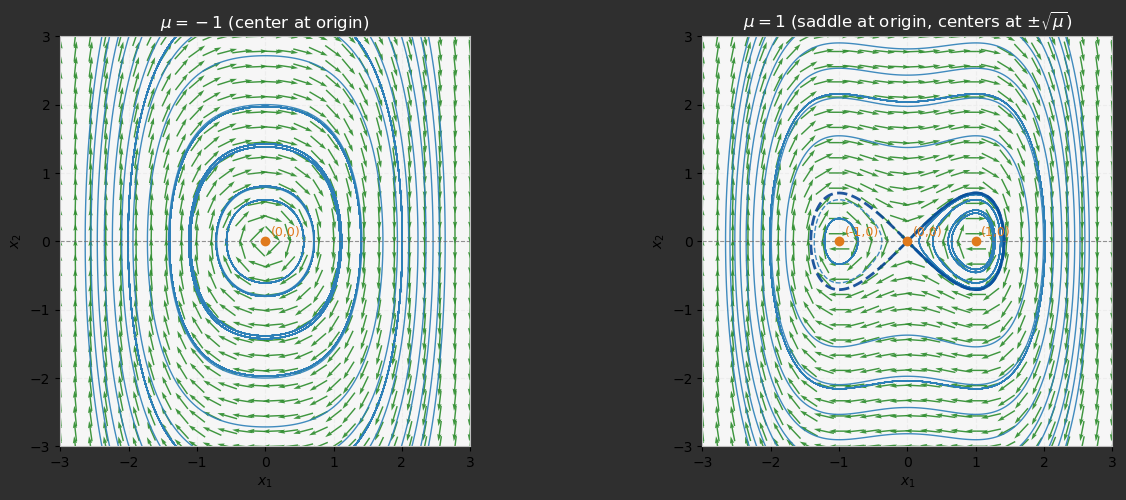

In [10]:
import numpy as np, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

f = lambda t,z,mu: [z[1], mu*z[0] - z[0]**3]
H = lambda x1,x2,mu: 0.5*x2**2 - 0.5*mu*x1**2 + 0.25*x1**4
h_pos = lambda x1,mu: x1*np.sqrt(np.maximum(mu - 0.5*x1**2, 0.0))

def plot_panel(ax, mu, xlim=(-3,3), ylim=(-3,3)):
    ax.set_facecolor('#f6f6f6'); ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')
    # vector field
    nx = ny = 28
    X,Y = np.meshgrid(np.linspace(*xlim,nx), np.linspace(*ylim,ny))
    U, V = Y, mu*X - X**3
    M = np.hypot(U,V); M[M==0]=1
    ax.quiver(X, Y, U/M, V/M, color='#2b8c2b', scale=20, width=0.0035, alpha=0.9, pivot='mid')
    # equilibria
    eqs = [(0.0,0.0)] + ([(np.sqrt(mu),0.0),(-np.sqrt(mu),0.0)] if mu>0 else [])
    for ex,ey in eqs:
        ax.plot(ex,ey,'o',color='#E07A1D',markersize=6,zorder=6); ax.text(ex+0.08,ey+0.08,f"({ex:.2g},0)",color='#E07A1D',fontsize=9)
    # Hamiltonian contours
    xg = np.linspace(*xlim,400); yg = np.linspace(*ylim,400)
    XX,YY = np.meshgrid(xg,yg); HH = H(XX,YY,mu)
    levels = np.linspace(np.percentile(HH,5), np.percentile(HH,85), 10)
    ax.contour(XX,YY,HH, levels=levels, colors='#2c7fb8', linewidths=1.0, alpha=0.9)
    ax.contour(XX,YY,HH, levels=[0.0], colors='#084594', linewidths=2.0, linestyles='--', alpha=0.9)
    # sample trajectories
    inits = [(0.7,0.2),(1.05,0.45),(1.4,0.1),(0.5,-0.3),(-1.1,0.3),(-2.0,-0.4)]
    tf = 80.0 if mu <= 0 else 40.0
    t_eval = np.linspace(0,tf,2000)
    for x0 in inits:
        sol = solve_ivp(f,[0,tf],x0,args=(mu,),t_eval=t_eval,rtol=1e-9,atol=1e-12)
        ax.plot(sol.y[0],sol.y[1],color='#2c7fb8',linewidth=0.9,alpha=0.9)
        solb = solve_ivp(f,[0,-tf],x0,args=(mu,),t_eval=np.linspace(0,-tf,2000),rtol=1e-9,atol=1e-12)
        ax.plot(solb.y[0],solb.y[1],color='#2c7fb8',linewidth=0.9,alpha=0.9)
    # analytic homoclinic if present
    if mu>0:
        xs = np.linspace(1e-6, np.sqrt(2*mu)-1e-6, 600); hp = h_pos(xs,mu)
        ax.plot(xs, hp, color='#08519c', lw=2.0, alpha=0.95); ax.plot(xs, -hp, color='#08519c', lw=2.0, alpha=0.95)
    ax.axhline(0,color='#6b6b6b',ls='--',lw=0.8,alpha=0.7); ax.grid(alpha=0.12,linestyle='--')
    ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")

if __name__ == "__main__":
    plt.rcParams.update({'font.size':10,'figure.facecolor':'#2f2f2f'})
    fig, axs = plt.subplots(1,2,figsize=(13,5),facecolor='#2f2f2f')
    plot_panel(axs[0], mu=-1.0); axs[0].set_title(r"$\mu=-1$ (center at origin)", color='white', fontsize=12)
    plot_panel(axs[1], mu=1.0);  axs[1].set_title(r"$\mu=1$ (saddle at origin, centers at $\pm\sqrt{\mu}$)", color='white', fontsize=12)
    for ax in axs:
        ax.tick_params(colors='black')
        for s in ax.spines.values(): s.set_edgecolor('#bfbfbf')
    plt.subplots_adjust(left=0.06,right=0.94,top=0.92,bottom=0.10,wspace=0.28)
    plt.show()

### 1.D

For $\mu>0$ the phase portrait shows a homoclinic loop that leaves the saddle at $(0,0)$ and returns to it.
In the first quadrant $(x_1>0, x_2>0)$ we can describe this homoclinic orbit as the graph of a $C^1$ function
$x_2 = h(x_1)$,
which is a one-to-one mapping in the region where the homoclinic orbit lies.
From the system we know $\dot{x_1} = x_2$, thereby we obtain:
$$\dot{x_2} = \dot{x_1}h(x_1) = h(x_1)h'(x_1)=\mu x_1 - x_1^{3}$$

The condition h needs to satisfy is:
$$h(x_1)h'(x_1) = \mu x_1 - x_1^3$$
This can be written as:
$$h(x_1)\frac{dh(x_1)}{dx_1} = \mu x_1 - x_1^3 \rightarrow h(x_1)dh = (\mu x_1 - x_1^3)dx_1$$

Then we take the integral of both sides and isolate for h(x_1):
$$\frac{1}{2}h^2(x_1) + C_1 = \frac{\mu}{2}x_1^2 - \frac{1}{4}x_1^4 + C_2 \rightarrow h^2(x_1) = \mu x_1^2 - \frac{1}{2}x_1^4 + C \rightarrow h(x_1)= \sqrt(\mu x_1^2 - \frac{1}{2}x_1^4 + C)$$

We will now determine C, by using the saddle point obtained in the previous problem at $(0,0)$ for $\mu>0$, we insert $x_1=x_2=0$ for $h(x_1)$:

$$x_2 = 0=h(x_1) = h(0) = \sqrt(\mu 0^2 -\frac{1}{2}0^4+C) \rightarrow \sqrt(C) = 0 \rightarrow = C =0$$
Therefore:
$$h(x_1) = \sqrt(\mu x_1^2-\frac{1}{2}x_1^4) = x^2\sqrt(\mu - \frac{1}{2}x1^2)
$$
We have now solved the first order ODE analytically, and obtained an expression for $h(x_1)$

### 1.E

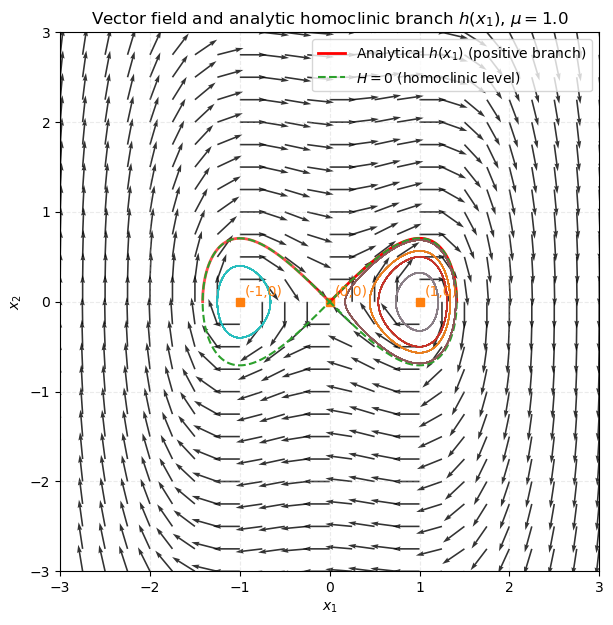

In [4]:
# System
def f(t, z, mu):
    x1, x2 = z
    return [x2, mu*x1 - x1**3]

# Hamiltonian (for optional contour)
def H(x1, x2, mu):
    return 0.5*x2**2 - 0.5*mu*x1**2 + 0.25*x1**4

# Analytical h(x1) positive branch in first quadrant
def h_analytic(x1, mu):
    # valid for 0 < x1 < sqrt(2*mu)
    inside = mu - 0.5 * x1**2
    inside = np.maximum(inside, 0.0)   # avoid negative round-off
    return x1 * np.sqrt(inside)

def plot_with_h(mu=1.0, xlim=(-3,3), ylim=(-3,3)):
    fig, ax = plt.subplots(figsize=(7,7))

    # vector field grid
    nx, ny = 25, 25
    x1 = np.linspace(xlim[0], xlim[1], nx)
    x2 = np.linspace(ylim[0], ylim[1], ny)
    X1, X2 = np.meshgrid(x1, x2)
    U = X2
    V = mu*X1 - X1**3
    M = np.hypot(U, V)
    M[M == 0] = 1.0
    ax.quiver(X1, X2, U/M, V/M, angles='xy', scale=20, width=0.003, alpha=0.8)

    # equilibria
    eq_pts = [(0.0,0.0)]
    if mu > 0:
        eq_pts += [(np.sqrt(mu),0.0),(-np.sqrt(mu),0.0)]
    for (ex,ey) in eq_pts:
        ax.plot(ex, ey, 's', color='C1', markersize=6)
        ax.text(ex+0.06, ey+0.06, f"({ex:.2g},0)", color='C1')

    # Plot analytic h(x1) (first-quadrant positive branch)
    if mu > 0:
        x1_pos = np.linspace(1e-6, np.sqrt(2*mu)-1e-6, 400)
        h_pos = h_analytic(x1_pos, mu)
        ax.plot(x1_pos, h_pos, color='red', lw=2, label=r'Analytical $h(x_1)$ (positive branch)')

        # also mirror negative-x1 branch (symmetric)
        ax.plot(-x1_pos, h_pos, color='red', lw=2, alpha=0.7)

    # Hamiltonian H=0 contour (this will trace the homoclinic loop)
    xs = np.linspace(xlim[0], xlim[1], 400)
    ys = np.linspace(ylim[0], ylim[1], 400)
    XX, YY = np.meshgrid(xs, ys)
    HH = H(XX, YY, mu)
    # Plot the zero-level contour; sometimes there are tiny numerical artifacts so check existence
    cs = ax.contour(XX, YY, HH, levels=[0.0], colors='C2', linewidths=1.5, linestyles='--')
    if len(cs.allsegs[0]) > 0:
        ax.plot([], [], 'C2--', label=r'$H=0$ (homoclinic level)')

    # sample trajectories (forward and backward) to show orbits
    init_conds = [
        (0.5, 0.2),
        (1.0, 0.5),
        (1.4, 0.1),
        (0.8, -0.2),
        (-1.0, 0.4)
    ]
    t_fwd = 80.0  # longer for periodic-like orbits
    t_eval = np.linspace(0, t_fwd, 2000)
    for x0 in init_conds:
        sol_f = solve_ivp(f, [0, t_fwd], x0, args=(mu,), t_eval=t_eval, rtol=1e-9, atol=1e-12)
        ax.plot(sol_f.y[0], sol_f.y[1], lw=0.9, alpha=0.9)
        sol_b = solve_ivp(f, [0, -t_fwd], x0, args=(mu,), t_eval=np.linspace(0, -t_fwd, 2000), rtol=1e-9, atol=1e-12)
        ax.plot(sol_b.y[0], sol_b.y[1], lw=0.9, alpha=0.9)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(fr"Vector field and analytic homoclinic branch $h(x_1)$, $\mu={mu}$")
    ax.grid(alpha=0.25, linestyle='--')
    ax.legend(loc='upper right')
    ax.set_aspect('equal', adjustable='box')
    plt.show()

if __name__ == "__main__":
    # Example: plot for mu = 1 (homoclinic present)
    plot_with_h(mu=1.0, xlim=(-3,3), ylim=(-3,3))

    # If you also want a plot for mu < 0 to compare (no homoclinic),
    # uncomment the following line:
    # plot_with_h(mu=-1.0, xlim=(-3,3), ylim=(-3,3))

In the figure above we see the analytical expressions for $h$ together with the vector field, we expected a homoclinical orbit similar to figure 2 page 206 in Perko. Comparing it with the figure in 1.C, the result is very much expected.

### 1.F

In the first quadrant $(x_1>0,\; x_2>0)$ we previously found that the homoclinic orbit is given by
$$x_2 = h(x_1) = \sqrt(\mu x_1^2-\frac{1}{2}x_1^4)$$
To obtain the branch of the same homoclinic orbit in the fourth quadrant $(x_1>0,\; x_2<0)$, we simply reverse the sign of $x_2$.
Since $x_2 = h(x_1)$ in the first quadrant, in the fourth quadrant we must have:
$$-x_2 = -h(x_1) = -\sqrt(\mu x_1^2 - \frac{1}{2}x_1^4)$$